# Motorcars

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline


## Laden

In [26]:
df = pd.read_csv('./mtcars.csv')

## Exploration

In [27]:
df.shape

(32, 12)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   model   32 non-null     object 
 1   mpg     32 non-null     float64
 2   cyl     32 non-null     int64  
 3   disp    32 non-null     float64
 4   hp      32 non-null     int64  
 5   drat    32 non-null     float64
 6   wt      32 non-null     float64
 7   qsec    32 non-null     float64
 8   vs      32 non-null     int64  
 9   am      32 non-null     int64  
 10  gear    32 non-null     int64  
 11  carb    32 non-null     int64  
dtypes: float64(5), int64(6), object(1)
memory usage: 3.1+ KB


* Bedeutung der Spalten
  * model = Name
  * mpg = Miles per Gallon
  * cyl = Anzahl der Zylinder
  * displacement = Hubraum
  * hp = PS
  * drat = Achsenübersetzung
  * wt = Gewicht
  * qsec = "Quarter Mile Time"
  * vs = Motortyp, 0=V-Shaped, 1 = normal
  * am = Gangschaltung, 0=automatisch, 1=manuell
  * gear = Anzahl Gänge ohne Rückwärtsgang
  * carb = Anzahl der Vergaser (= carburetors)

* Ergebnis
  * Fast alles numerisch
  * Kandidaten Kategorien
    * cyl, vs, am und gear, carb
    * Model

In [29]:
df.describe()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.0000
mean,20.090625,6.187500,230.721875,146.687500,3.596563,3.217250,17.848750,0.437500,0.406250,3.687500,2.8125
std,6.026948,1.785922,123.938694,68.562868,0.534679,0.978457,1.786943,0.504016,0.498991,0.737804,1.6152
min,10.400000,4.000000,71.100000,52.000000,2.760000,1.513000,14.500000,0.000000,0.000000,3.000000,1.0000
25%,15.425000,4.000000,120.825000,96.500000,3.080000,2.581250,16.892500,0.000000,0.000000,3.000000,2.0000
50%,19.200000,6.000000,196.300000,123.000000,3.695000,3.325000,17.710000,0.000000,0.000000,4.000000,2.0000
75%,22.800000,8.000000,326.000000,180.000000,3.920000,3.610000,18.900000,1.000000,1.000000,4.000000,4.0000
max,33.900000,8.000000,472.000000,335.000000,4.930000,5.424000,22.900000,1.000000,1.000000,5.000000,8.0000


In [30]:
df['model'].nunique()

32

* model ist nicht sinnvoll kategorisierbar, hat ja soviele Werte wie der gesamte Datensatz

In [31]:
category_candidates = ('cyl', 'vs', 'am', 'gear', 'carb')
for column in category_candidates:
    print(f'{column} has {df[column].nunique()} values')


cyl has 3 values
vs has 2 values
am has 2 values
gear has 3 values
carb has 6 values


* Ergebnis
  * cyl, vs, am, gear, carb sind kategorisierbar
  

In [32]:
for column in category_candidates:
    df[column] = pd.Categorical(df[column])
df.info()    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   model   32 non-null     object  
 1   mpg     32 non-null     float64 
 2   cyl     32 non-null     category
 3   disp    32 non-null     float64 
 4   hp      32 non-null     int64   
 5   drat    32 non-null     float64 
 6   wt      32 non-null     float64 
 7   qsec    32 non-null     float64 
 8   vs      32 non-null     category
 9   am      32 non-null     category
 10  gear    32 non-null     category
 11  carb    32 non-null     category
dtypes: category(5), float64(5), int64(1), object(1)
memory usage: 2.8+ KB


In [33]:
df.describe()

,mpg,disp,hp,drat,wt,qsec
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000
mean,20.090625,230.721875,146.687500,3.596563,3.217250,17.848750
std,6.026948,123.938694,68.562868,0.534679,0.978457,1.786943
min,10.400000,71.100000,52.000000,2.760000,1.513000,14.500000
25%,15.425000,120.825000,96.500000,3.080000,2.581250,16.892500
50%,19.200000,196.300000,123.000000,3.695000,3.325000,17.710000
75%,22.800000,326.000000,180.000000,3.920000,3.610000,18.900000
max,33.900000,472.000000,335.000000,4.930000,5.424000,22.900000


* Verteilung der Daten

<Axes: >

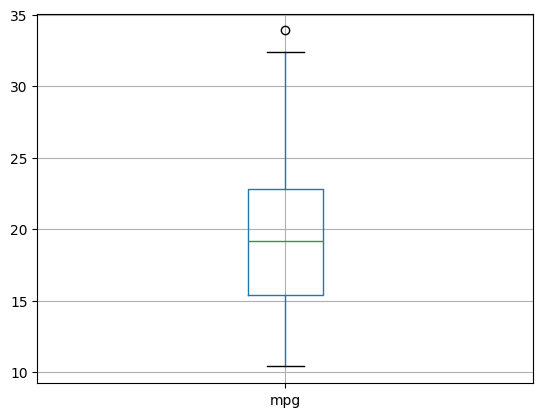

In [34]:
df.boxplot('mpg')

<Axes: title={'center': 'mpg'}, xlabel='vs'>

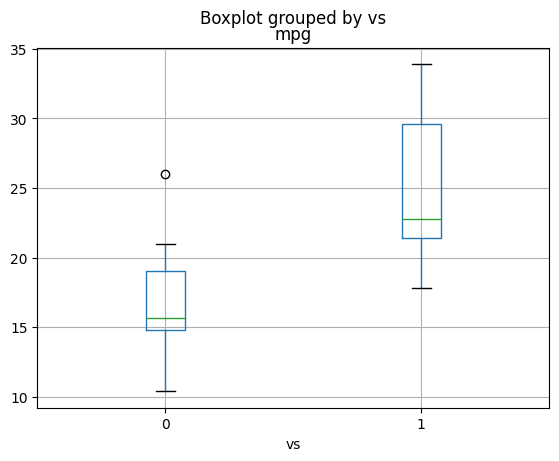

In [35]:
df.boxplot('mpg', by='vs')

<Axes: title={'center': 'hp'}, xlabel='cyl'>

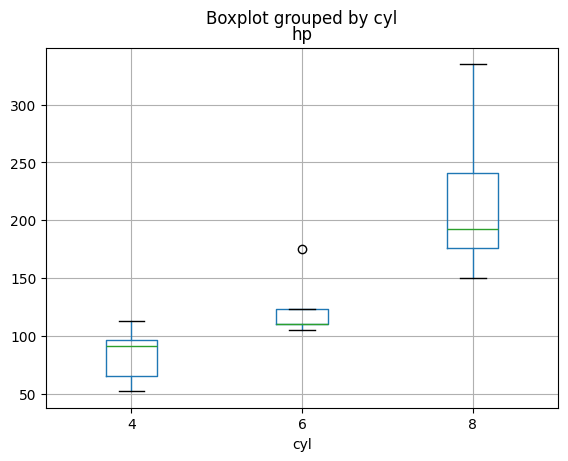

In [36]:
df.boxplot('hp', by='cyl')

<Axes: title={'center': 'wt'}, xlabel='cyl'>

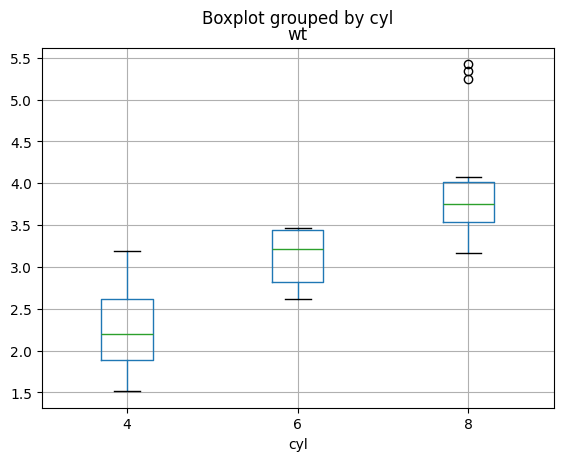

In [37]:
df.boxplot('wt', by='cyl')

array([[<Axes: title={'center': 'mpg'}>]], dtype=object)

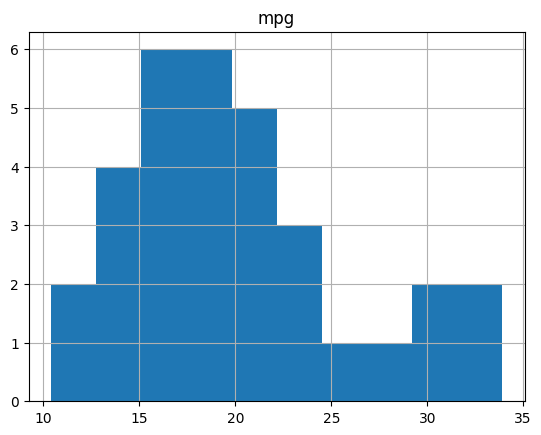

In [38]:
df.hist('mpg', bins=10)

/tmp/ipykernel_77561/1610424952.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.hist('mpg', 'cyl')


array([[<Axes: title={'center': '4'}>, <Axes: title={'center': '6'}>],
       [<Axes: title={'center': '8'}>, <Axes: >]], dtype=object)

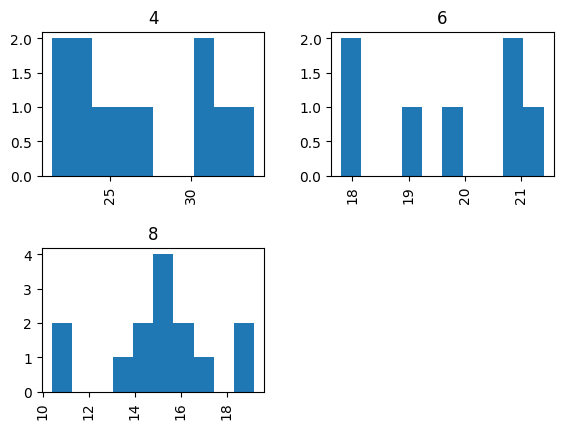

In [39]:
df.hist('mpg', 'cyl')

### Schauen wir uns potenziellen Zusammenhänge an:

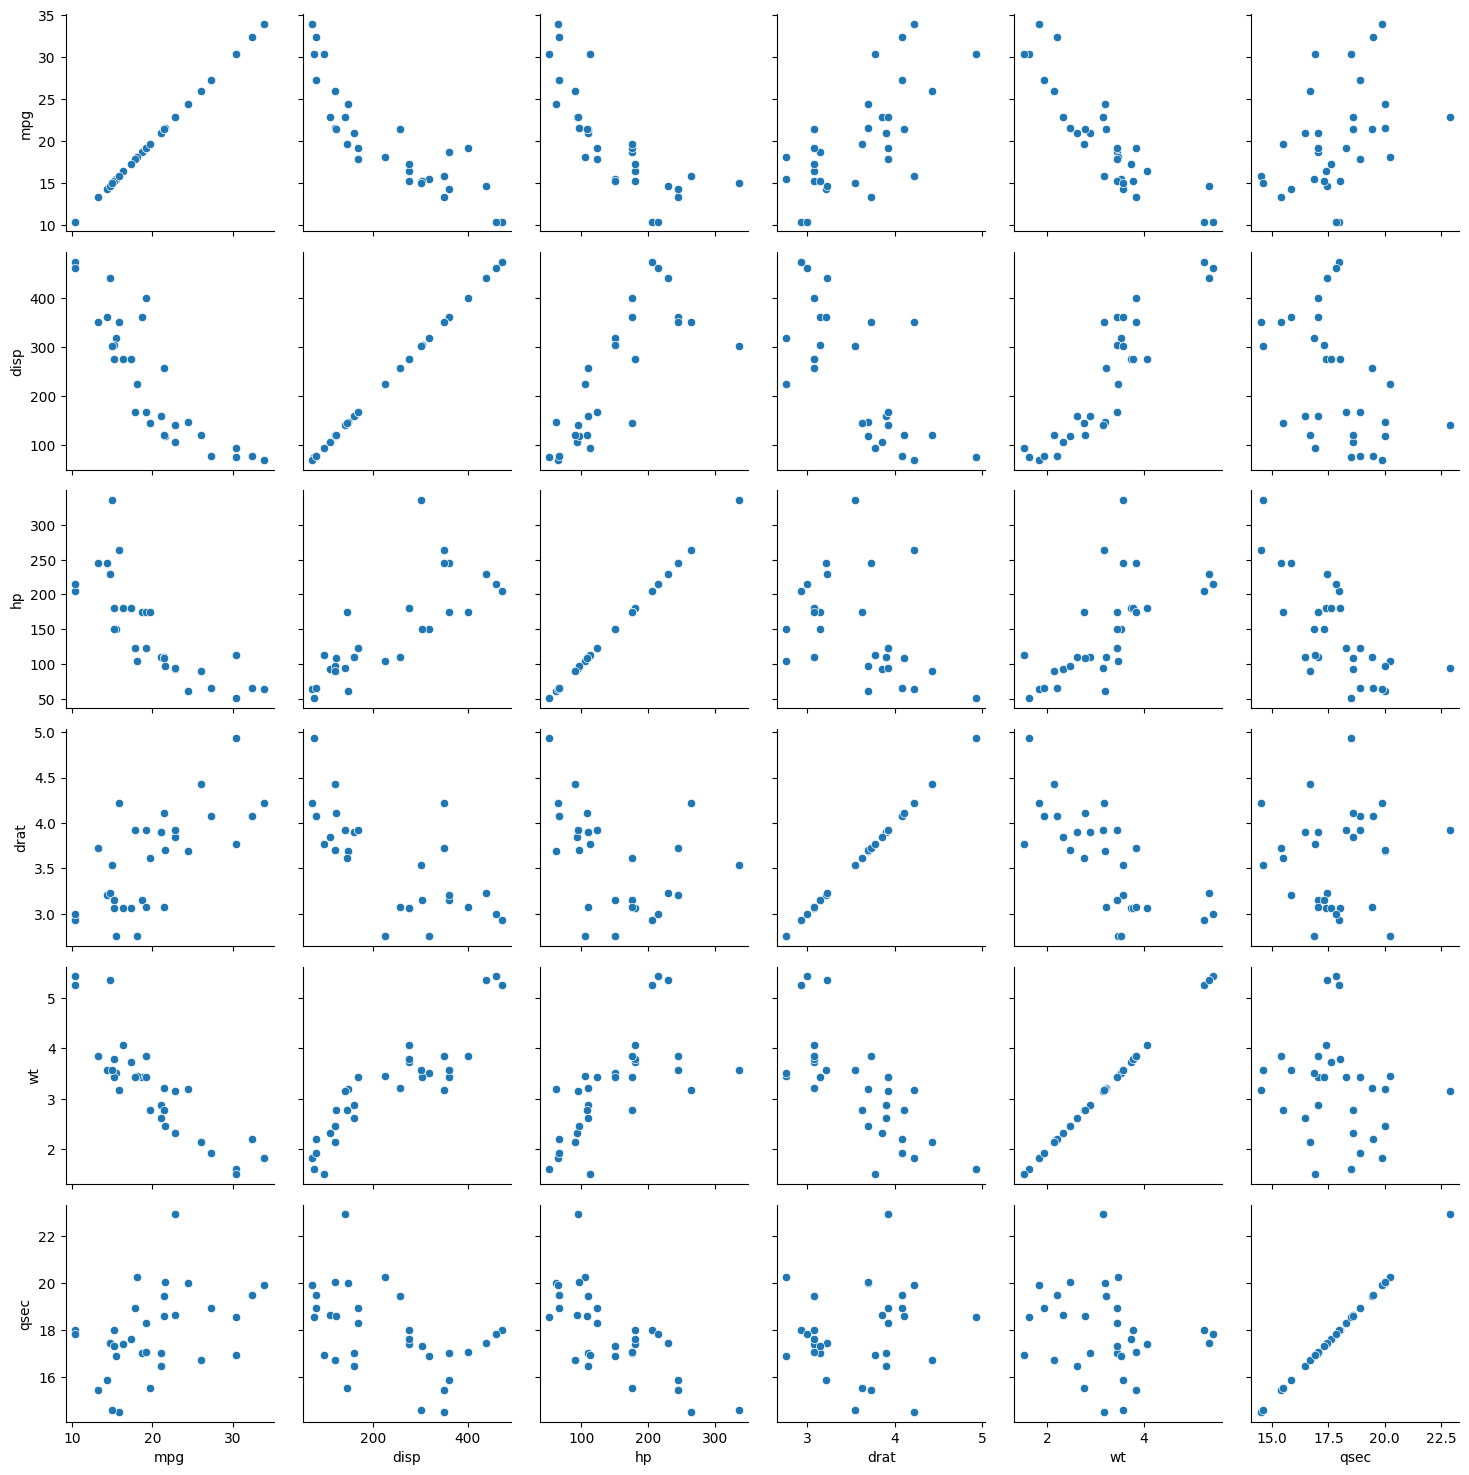

In [40]:
plots = sns.PairGrid(df)
plots.map(sns.scatterplot)

* oder als Heatmap

<Axes: >

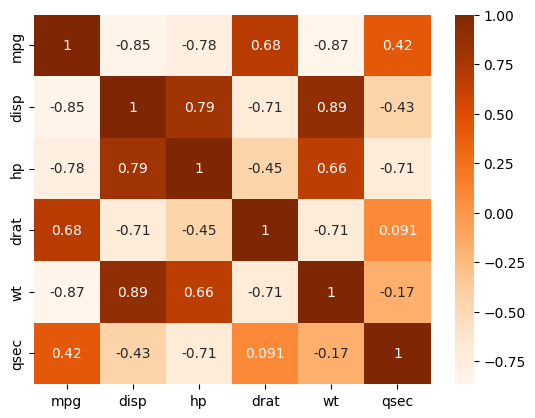

In [41]:
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='Oranges')

## Analyse

### Deskriptive Statistik

* Übersicht

In [42]:
df.describe()

,mpg,disp,hp,drat,wt,qsec
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000
mean,20.090625,230.721875,146.687500,3.596563,3.217250,17.848750
std,6.026948,123.938694,68.562868,0.534679,0.978457,1.786943
min,10.400000,71.100000,52.000000,2.760000,1.513000,14.500000
25%,15.425000,120.825000,96.500000,3.080000,2.581250,16.892500
50%,19.200000,196.300000,123.000000,3.695000,3.325000,17.710000
75%,22.800000,326.000000,180.000000,3.920000,3.610000,18.900000
max,33.900000,472.000000,335.000000,4.930000,5.424000,22.900000


* Skewness
  * Wie schief sind die Daten im Vergleich zu einer Normalverteilung
  * bzw. gibt es Schultern, mehrere Maxima 

In [43]:
df['mpg'].skew()

np.float64(0.6723771376290805)

* Kurtosis
  * "Wölbung" im Vergleich zu einer Normalverteilung
  * ist die Verteilung enger oder weiter?

In [44]:
df['mpg'].kurt()

np.float64(-0.0220062914240855)

* Darstellung im Density-Plot
  * Ein Density Plot ist eine Abart eines Histogramms, das vereinfacht unendlich viele bins hat und zusätzlich noch eine Mittelung vornimmt, um Zacken zu vermeiden

<Axes: ylabel='Density'>

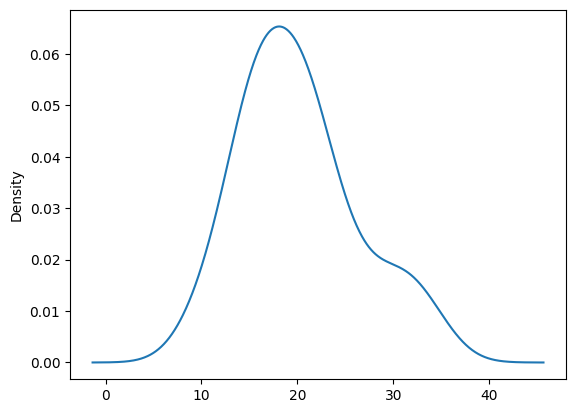

In [45]:
df['mpg'].plot(kind='density')

* wt und hp

In [46]:
print(f'Skewness weight: {df['wt'].skew()}')
print(f'Kurtosis weight: {df['wt'].kurt()}')
print(f'Skewness horsepower: {df['hp'].skew()}')
print(f'Kurtosis horsepower: {df['hp'].kurt()}')

Skewness weight: 0.4659161067929858
Kurtosis weight: 0.416594669634927
Skewness horsepower: 0.7994066925956381
Kurtosis horsepower: 0.2752115875371124


<Axes: ylabel='Density'>

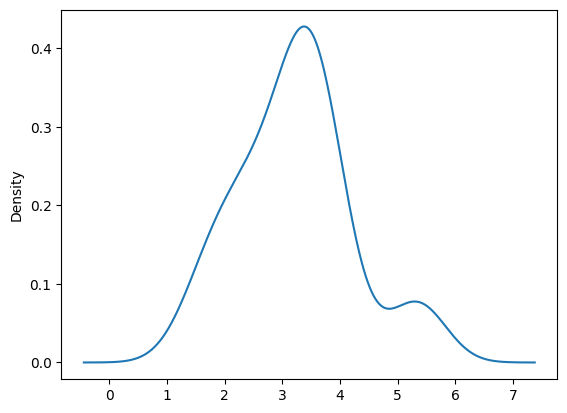

In [47]:
df['wt'].plot(kind='density')

<Axes: ylabel='Density'>

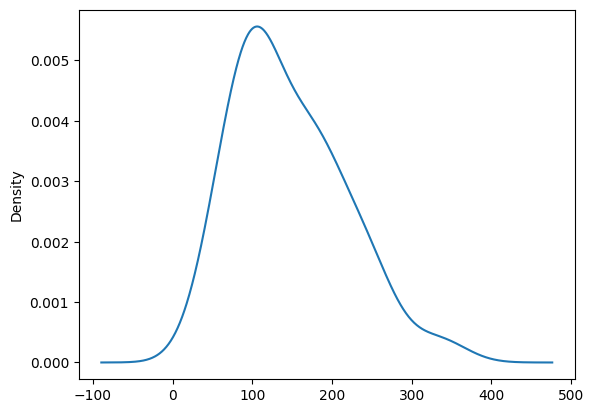

In [48]:
df['hp'].plot(kind='density')

## Regressionsanalyse

<Axes: xlabel='wt', ylabel='mpg'>

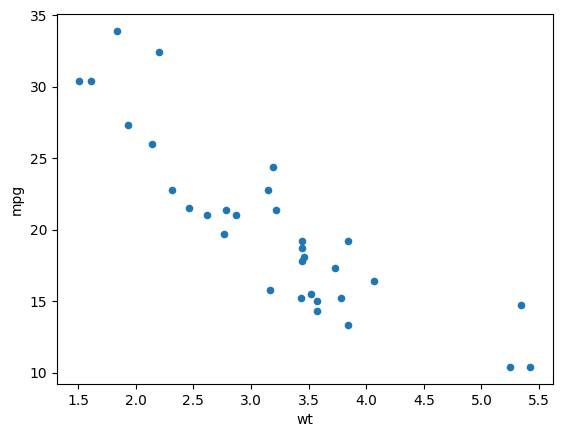

In [49]:
df.plot(kind='scatter', x='wt', y='mpg')

* Wir machen nun die Regressionsanalyse
  * Lineare Regression

In [50]:
from sklearn import linear_model # pip install scikit-learn 

In [51]:
regression_model = linear_model.LinearRegression()
regression_model.fit(X=pd.DataFrame(df['wt']), y = df['mpg'])
print(f'Achsenabschnitt: {regression_model.intercept_}')
print(f'Steigung: {regression_model.coef_}')

Achsenabschnitt: 37.28512616734204
Steigung: [-5.34447157]


In [52]:
predicted = regression_model.predict(X=pd.DataFrame(df['wt']))

In [53]:
residuals = df['mpg'] - predicted
residuals

0    -2.282611
1    -0.919770
2    -2.085952
3     1.297350
4    -0.200144
5    -0.693255
6    -3.905363
7     4.163738
8     2.349959
9     0.299856
10   -1.100144
11    0.866873
12   -0.050247
13   -1.883024
14    1.173350
15    2.103288
16    5.981074
17    6.872711
18    1.746195
19    6.421979
20   -2.611004
21   -2.972586
22   -3.726866
23   -3.462355
24    2.464367
25    0.356426
26    0.152043
27    1.201059
28   -4.543151
29   -2.780940
30   -3.205363
31   -1.027495
Name: mpg, dtype: float64

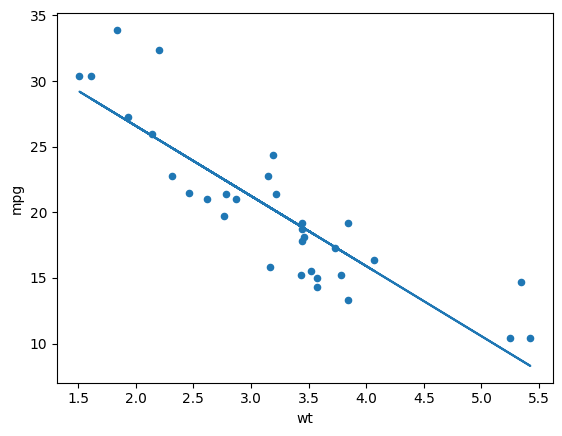

In [54]:
df.plot(kind='scatter', x='wt', y='mpg')
plt.plot(df['wt'].to_numpy(), predicted)

In [55]:
regression_model.score(X=pd.DataFrame(df['wt']), y=df['mpg'])

0.7528327936582646

In [56]:
import scipy.stats as stats

((array([-2.02511189, -1.62590278, -1.38593914, -1.20666642, -1.05953591,
         -0.93235918, -0.81872017, -0.71478609, -0.6180591 , -0.52680137,
         -0.43973827, -0.35589149, -0.27447843, -0.19484777, -0.11643566,
         -0.03873405,  0.03873405,  0.11643566,  0.19484777,  0.27447843,
          0.35589149,  0.43973827,  0.52680137,  0.6180591 ,  0.71478609,
          0.81872017,  0.93235918,  1.05953591,  1.20666642,  1.38593914,
          1.62590278,  2.02511189]),
  array([-4.54315128, -3.90536265, -3.72686632, -3.46235533, -3.20536265,
         -2.97258623, -2.78093991, -2.61100374, -2.28261065, -2.08595212,
         -1.88302362, -1.10014396, -1.0274952 , -0.9197704 , -0.69325453,
         -0.20014396, -0.0502472 ,  0.152043  ,  0.29985604,  0.35642633,
          0.86687313,  1.17334959,  1.20105932,  1.29734994,  1.74619542,
          2.10328764,  2.34995929,  2.46436703,  4.16373815,  5.98107439,
          6.42197917,  6.87271129])),
 (np.float64(3.0327797489458974),
  n

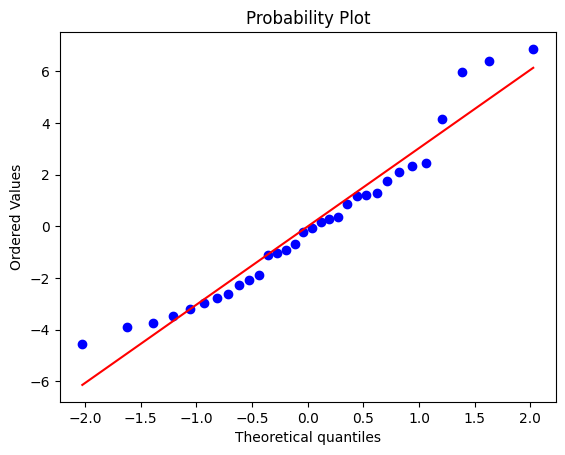

In [57]:
stats.probplot(residuals, dist='norm', plot=plt)

* Polynome Regression
  * 2. Ordnung = Statt Ausgleichsgerade nehmen wir eine Parabel

In [58]:
poly_model = linear_model.LinearRegression()
x_axis = pd.DataFrame([df['wt'], df['wt']**2]).T
poly_model.fit(X=x_axis, y=df['mpg'])
print(f'Achenabschnitt: {poly_model.intercept_}')
print(f'Koeffizienten: {poly_model.coef_}')
print(f"Score: {poly_model.score(x_axis, y=df['mpg'])}")


Achenabschnitt: 49.93081094945181
Koeffizienten: [-13.38033708   1.17108689]
Score: 0.8190613581384094


/home/sl01/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


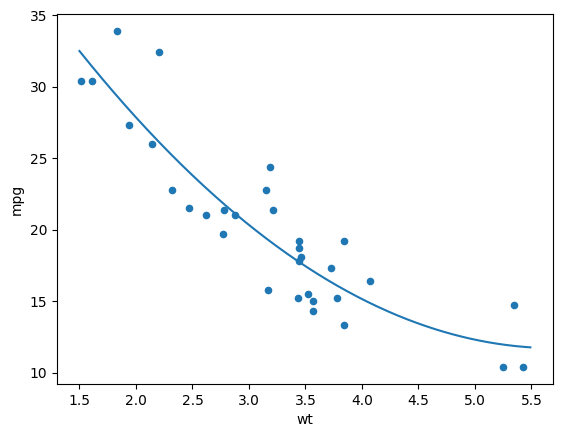

In [59]:
df.plot(kind='scatter', x='wt', y='mpg')
poly_range = np.arange(1.5, 5.5,0.01)
predicted = poly_model.predict(pd.DataFrame([poly_range, poly_range**2]).T)
plt.plot(poly_range, predicted)


   * Hinzufügen weiterer Potenzen, in den meisten Fällen sinnlos, da nie physikalisch begründbar

In [60]:
useless_poly_model = linear_model.LinearRegression()
x_axis = pd.DataFrame([
    df['wt'], 
    df['wt']**2,
    df['wt']**3,
    df['wt']**4,
    df['wt']**5,
    df['wt']**6,
    df['wt']**7,
    df['wt']**8,
    df['wt']**9,
    ]).T
useless_poly_model.fit(X=x_axis, y=df['mpg'])
print(f'Achenabschnitt: {useless_poly_model.intercept_}')
print(f'Koeffizienten: {useless_poly_model.coef_}')
print(f"Score: {useless_poly_model.score(x_axis, y=df['mpg'])}")

Achenabschnitt: 38889.610982410486
Koeffizienten: [-1.25317628e+05  1.74784059e+05 -1.38423294e+05  6.86522656e+04
 -2.21343938e+04  4.64432999e+03 -6.12230173e+02  4.60606389e+01
 -1.50849986e+00]
Score: 0.8646786784285899


/home/sl01/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


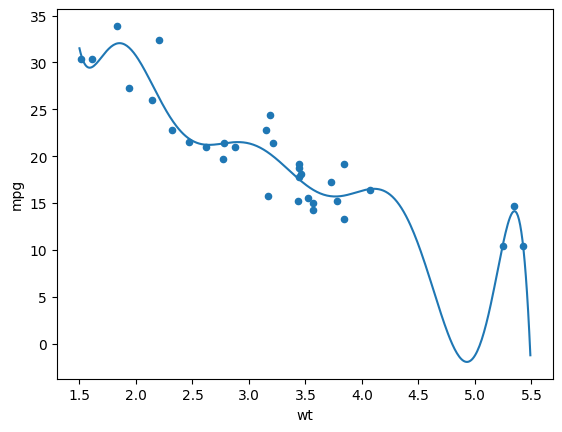

In [61]:
df.plot(kind='scatter', x='wt', y='mpg')
useless_predicted = useless_poly_model.predict(pd.DataFrame([
    poly_range, 
    poly_range**2,
    poly_range**3,
    poly_range**4,
    poly_range**5,
    poly_range**6,
    poly_range**7,
    poly_range**8,
    poly_range**9,
    ]).T)
plt.plot(poly_range, useless_predicted)


* Multiple Linear Regression

In [62]:
multi_reg_model = linear_model.LinearRegression()

# Include squared terms
poly_predictors = pd.DataFrame([df["wt"],
                                df["hp"],
                                df["wt"]**2,
                                df["hp"]**2]).T

# Train the model using the mtcars data
multi_reg_model.fit(X = poly_predictors, 
                    y = df["mpg"])
print(f'Achenabschnitt: {multi_reg_model.intercept_}')
print(f'Koeffizienten: {multi_reg_model.coef_}')
print(f"Score: {multi_reg_model.score(poly_predictors, y=df['mpg'])}")


Achenabschnitt: 49.453049353183104
Koeffizienten: [-9.22032201e+00 -9.42795055e-02  8.50005416e-01  1.74322164e-04]
Score: 0.8907279549670641
